# 35 — ProtoSegNetV2: No-Skip Prototype-Only Training
**Stage 9 · Prototype as sole prediction pathway · no decoder · no skip connections**

Covers:
1. Architecture inspection — shapes, bypass invariant, parameter counts
2. Smoke test — forward pass, loss, gradient flow
3. Training — 3-phase schedule for Stage 9a / 9b / 9c
4. Training curves — loss components + val Dice per phase
5. Attention weight evolution (Stage 9c only)

| Stage | Config | Key question |
|-------|--------|--------------|
| 9a | L4 only, no attention | Does removing bypass fix XAI? |
| 9b | L3+L4, uniform | Does multi-scale help in the clean setting? |
| 9c | L1–L4, learned attention | Does attention add value over fixed multi-scale? |

**Structural guarantee:** `logits = f(heatmaps)` only — no encoder features bypass the prototype layer.

**Training time estimate:** ~100 ep × 85s/ep ≈ 2.4h CT, 1.2h MRI (MPS, batch=16)

In [1]:
import sys, os

_root = os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) == 'notebooks' else os.getcwd()
os.chdir(_root)
sys.path.insert(0, _root)
os.environ.setdefault('PYTORCH_MPS_HIGH_WATERMARK_RATIO', '0.0')
os.environ.setdefault('PYTORCH_ENABLE_MPS_FALLBACK', '1')

import csv
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from pathlib import Path

from src.data.mmwhs_dataset import (
    MMWHSSliceDataset, make_dataloaders, LABEL_NAMES, NUM_CLASSES,
)
from src.models.proto_seg_net_v2 import ProtoSegNetV2, LevelAttentionModule
from src.models.prototype_layer import PrototypeProjection, PROTOS_PER_LEVEL
from src.losses.segmentation import SegmentationLoss, compute_class_weights
from src.losses.diversity_loss import ProtoSegLoss
from src.metrics.dice import dice_per_class, mean_foreground_dice

DEVICE     = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
DATA_DIR   = 'data/pack/processed_data'
CKPT_DIR   = Path('checkpoints')
RESULT_DIR = Path('results/v9')
RESULT_DIR.mkdir(parents=True, exist_ok=True)

PHASE_COLORS = {'A': '#4C72B0', 'B': '#DD8452', 'C': '#55A868'}
FG_NAMES = [LABEL_NAMES[c] for c in range(1, NUM_CLASSES)]

print(f'Working dir : {os.getcwd()}')
print(f'Device      : {DEVICE}')

Working dir : /Users/amo/programData/cardiac-proto-segmentation
Device      : mps


---
## 1 · Architecture Inspection

In [2]:
# Tensor shapes for all three stage configs
x = torch.randn(2, 1, 256, 256)

configs = [
    ('9a', dict(proto_levels=(4,),      use_attention=False)),
    ('9b', dict(proto_levels=(3, 4),    use_attention=False)),
    ('9c', dict(proto_levels=(1,2,3,4), use_attention=True)),
]

for name, cfg in configs:
    m = ProtoSegNetV2(**cfg)
    m.eval()
    with torch.no_grad():
        logits, hm, w = m(x, T=1.0)
    print(f'Stage {name}  (levels={cfg["proto_levels"]}, attn={cfg["use_attention"]})')
    print(f'  logits : {tuple(logits.shape)}')
    for l, A in sorted(hm.items()):
        print(f'  hm[{l}]  : {tuple(A.shape)}')
    print(f'  w      : {tuple(w.shape)}  sum={w.sum(1).tolist()}')
    print()

Stage 9a  (levels=(4,), attn=False)
  logits : (2, 8, 256, 256)
  hm[4]  : (2, 8, 2, 16, 16)
  w      : (2, 1)  sum=[1.0, 1.0]

Stage 9b  (levels=(3, 4), attn=False)
  logits : (2, 8, 256, 256)
  hm[3]  : (2, 8, 2, 32, 32)
  hm[4]  : (2, 8, 2, 16, 16)
  w      : (2, 2)  sum=[1.0, 1.0]

Stage 9c  (levels=(1, 2, 3, 4), attn=True)
  logits : (2, 8, 256, 256)
  hm[1]  : (2, 8, 4, 128, 128)
  hm[2]  : (2, 8, 3, 64, 64)
  hm[3]  : (2, 8, 2, 32, 32)
  hm[4]  : (2, 8, 2, 16, 16)
  w      : (2, 4)  sum=[1.0, 1.0]



In [3]:
# Bypass invariant — critical structural test
# Replace proto_layer with zero-output module; logits must be exactly zero.
# (Zeroing prototype weights is NOT equivalent: L2 sim with p=0 is 1/(||z||²/C+1) ≠ 0)

class _ZeroHeatmap(nn.Module):
    def forward(self, z):
        B = z.size(0)
        return torch.zeros(B, 8, 2, z.size(2), z.size(3))

m_bypass = ProtoSegNetV2(proto_levels=(4,), use_attention=False)
m_bypass.proto_layers['4'] = _ZeroHeatmap()

x_test = torch.randn(2, 1, 256, 256)
with torch.no_grad():
    logits_zero, _, _ = m_bypass(x_test)

max_val = logits_zero.abs().max().item()
status  = '✅ PASS' if max_val < 1e-6 else f'❌ FAIL (max={max_val:.2e})'
print(f'Bypass invariant: {status}')
print(f'  max |logits| when proto_layer outputs zero = {max_val:.2e}')
print(f'  → No encoder features bypass the prototype layer.')

Bypass invariant: ✅ PASS
  max |logits| when proto_layer outputs zero = 0.00e+00
  → No encoder features bypass the prototype layer.


In [4]:
# Parameter counts per stage config
print(f'{'Stage':<8} {'Levels':<14} {'Encoder':>10} {'Proto':>8} {'Attn':>8} {'Total':>10}')
print('─' * 62)
for name, cfg in configs:
    m = ProtoSegNetV2(**cfg)
    c = m.count_parameters()
    print(f'{name:<8} {str(cfg["proto_levels"]):<14} '
          f'{c["encoder"]:>10,} {c["proto"]:>8,} {c["attention"]:>8,} {c["total"]:>10,}')

print()
print('PROTOS_PER_LEVEL:', PROTOS_PER_LEVEL)
print('  L1: 4 protos/class × 8 classes × 32 ch =', 4*8*32, 'params')
print('  L4: 2 protos/class × 8 classes × 256 ch =', 2*8*256, 'params')

Stage    Levels            Encoder    Proto     Attn      Total
──────────────────────────────────────────────────────────────
9a       (4,)            1,956,960    4,096        0  1,961,056
9b       (3, 4)          1,956,960    6,144        0  1,963,104
9c       (1, 2, 3, 4)    1,956,960    8,704   31,044  1,996,708

PROTOS_PER_LEVEL: {1: 4, 2: 3, 3: 2, 4: 2}
  L1: 4 protos/class × 8 classes × 32 ch = 1024 params
  L4: 2 protos/class × 8 classes × 256 ch = 4096 params


In [5]:
# Temperature effect on attention weights (Stage 9c)
m9c = ProtoSegNetV2(proto_levels=(1,2,3,4), use_attention=True)
m9c.eval()
x_t = torch.randn(1, 1, 256, 256)

print('Temperature effect on w (Stage 9c):')
print(f'  {'T':>6}  {'w_L1':>7} {'w_L2':>7} {'w_L3':>7} {'w_L4':>7}  note')
print('  ' + '─' * 52)
for T in [100.0, 5.0, 2.0, 1.0, 0.1]:
    with torch.no_grad():
        _, _, w = m9c(x_t, T=T)
    w = w.squeeze().tolist()
    note = 'uniform' if T >= 50 else ('sharp' if T <= 0.2 else '')
    print(f'  {T:>6.1f}  {w[0]:>7.4f} {w[1]:>7.4f} {w[2]:>7.4f} {w[3]:>7.4f}  {note}')

Temperature effect on w (Stage 9c):
       T     w_L1    w_L2    w_L3    w_L4  note
  ────────────────────────────────────────────────────
   100.0   0.2502  0.2499  0.2500  0.2499  uniform
     5.0   0.2534  0.2486  0.2506  0.2473  
     2.0   0.2586  0.2465  0.2515  0.2434  
     1.0   0.2673  0.2430  0.2529  0.2368  
     0.1   0.4427  0.1706  0.2548  0.1319  sharp


---
## 2 · Smoke Test

In [6]:
# Forward + backward for all three configs
w_ones    = torch.ones(8)
seg_loss_ = SegmentationLoss(class_weights=w_ones)
criterion_= ProtoSegLoss(seg_loss=seg_loss_, lambda_div=0.001,
                         lambda_push=0.5, lambda_pull=0.25)

x_s = torch.randn(4, 1, 256, 256)
y_s = torch.randint(0, 8, (4, 256, 256))

for name, cfg in configs:
    m = ProtoSegNetV2(**cfg)
    m.train(); m.unfreeze_all()
    logits, hm, w = m(x_s, T=2.0)
    out = criterion_(logits, y_s, hm)
    out['loss'].backward()

    # Check gradient flow
    enc_grad  = m.encoder.level1.down[0].weight.grad
    p4_grad   = m.proto_layers[str(max(cfg['proto_levels']))].prototypes.grad
    attn_grad = (m.level_attention.mlp[0].weight.grad
                 if m.level_attention else None)

    enc_ok  = '✓' if enc_grad  is not None and enc_grad.abs().sum()  > 0 else '✗'
    p4_ok   = '✓' if p4_grad   is not None and p4_grad.abs().sum()   > 0 else '✗'
    attn_ok = ('✓' if attn_grad is not None and attn_grad.abs().sum() > 0
                else ('n/a' if not cfg['use_attention'] else '✗'))

    print(f'Stage {name}: loss={out["loss"].item():.4f}  '
          f'D={out["dice_loss"].item():.4f}  '
          f'CE={out["ce_loss"].item():.4f}  '
          f'div={out["div_loss"].item():.4f}  '
          f'push={out["push_loss"].item():.4f}  '
          f'pull={out["pull_loss"].item():.4f}')
    print(f'  Gradients → encoder:{enc_ok}  proto_L{max(cfg["proto_levels"])}:{p4_ok}  attn:{attn_ok}')
    print()

Stage 9a: loss=1.4018  D=0.8750  CE=2.0796  div=6.9984  push=-0.3297  pull=0.3297
  Gradients → encoder:✓  proto_L4:✓  attn:n/a



Stage 9b: loss=1.4078  D=0.8750  CE=2.0795  div=13.9955  push=-0.3339  pull=0.3339
  Gradients → encoder:✓  proto_L4:✓  attn:n/a



Stage 9c: loss=1.4650  D=0.8750  CE=2.0794  div=76.8915  push=-0.3562  pull=0.3562
  Gradients → encoder:✓  proto_L4:✓  attn:✓



---
## 3 · Training

**Phase schedule:**
| Phase | Epochs | Encoder | Prototypes | Attention | Loss |
|-------|--------|---------|-----------|-----------|------|
| A | 1–20 | ✓ | **✓** | frozen | seg only — prototypes specialise |
| B | 21–80 | ✓ | ✓ | frozen ep 21–30, then ✓ | + div(exp) + push + pull |
| C | 81–100 | frozen | frozen | ✓ (9c) / frozen (9a,9b) | attention fine-tune |

**Diversity loss fix (vs. earlier runs):**
`exp(-D_J)` per pair (bounded [0,1]) instead of `1/(D_J+eps)` (unbounded).
When prototypes collapse at Phase B start, old loss = 1/eps = 1e8; new loss = exp(0) = 1.0.

In [7]:
# ── Training configuration ────────────────────────────────────────────────────
MODALITY   = 'ct'   # ← 'ct' or 'mr'
STAGE      = '9L1'  # ← '9a'..'9e', '9L1','9L2','9L3'

STAGE_CONFIGS = {
    '9a': dict(proto_levels=(4,),      use_attention=False, suffix='_v2_l4'),
    '9b': dict(proto_levels=(3, 4),    use_attention=False, suffix='_v2_l34'),
    '9c': dict(proto_levels=(1,2,3,4), use_attention=True,  suffix='_v2'),
    '9d': dict(proto_levels=(1,2,3,4), use_attention=True,  suffix='_v2_tfmin'),  # T_min=2.0 (failed: MLP logit magnitude bypasses T)
    # Per-level ablation: validate that L4 is optimal (justifies attention collapse)
    '9L1': dict(proto_levels=(1,),     use_attention=False, suffix='_v2_l1'),
    '9L2': dict(proto_levels=(2,),     use_attention=False, suffix='_v2_l2'),
    '9L3': dict(proto_levels=(3,),     use_attention=False, suffix='_v2_l3'),
}

cfg = STAGE_CONFIGS[STAGE]
PROTO_LEVELS  = cfg['proto_levels']
USE_ATTENTION = cfg['use_attention']
SUFFIX        = cfg['suffix']

# Hyperparameters
BATCH_SIZE          = 16
LR                  = 3e-4
WEIGHT_DECAY        = 1e-5
LAMBDA_DIV          = 0.01    # safe: exp(-D_J) ∈ [0,1]; was 0.001 with 1/(D_J+eps) → explosion
LAMBDA_PUSH         = 0.5
LAMBDA_PULL         = 0.25

# Phase schedule
PHASE_A_END         = 20     # Phase A: seg only → prototypes specialise
ATTN_WARMUP_END     = 30     # Phase B: attention frozen until this epoch (9c)
PHASE_B_END         = 80     # Phase B: div+push+pull added; periodic projection
PHASE_C_START       = 81
MAX_EPOCHS          = 100
VAL_EVERY           = 5
PATIENCE            = 15
PROJECTION_INTERVAL = 10     # project every 10 epochs in Phase B

# Temperature annealing (Stage 9c only)
T_START       = 5.0
T_END         = 1.0
ANNEAL_EPOCHS = 40
ANNEAL_START  = ATTN_WARMUP_END + 1   # ep 31

print(f'Stage {STAGE} | {MODALITY.upper()} | levels={PROTO_LEVELS} | attn={USE_ATTENTION}')
print(f'λ_div={LAMBDA_DIV}  λ_push={LAMBDA_PUSH}  λ_pull={LAMBDA_PULL}')
print(f'Phase A: ep 1–{PHASE_A_END} (seg only) | Phase B: ep {PHASE_A_END+1}–{PHASE_B_END} (all losses)')
print(f'Checkpoint → checkpoints/proto_seg_{MODALITY}{SUFFIX}.pth')

Stage 9L1 | CT | levels=(1,) | attn=False
λ_div=0.01  λ_push=0.5  λ_pull=0.25
Phase A: ep 1–20 (seg only) | Phase B: ep 21–80 (all losses)
Checkpoint → checkpoints/proto_seg_ct_v2_l1.pth


In [8]:
# ── Helper functions ──────────────────────────────────────────────────────────

def compute_temperature(epoch):
    """T decays from T_START to T_END over ANNEAL_EPOCHS starting at ANNEAL_START."""
    if not USE_ATTENTION or epoch < ANNEAL_START:
        return T_START
    progress = (epoch - ANNEAL_START) / max(ANNEAL_EPOCHS, 1)
    return max(T_END, T_START * (T_END / T_START) ** min(progress, 1.0))


@torch.no_grad()
def validate_slices(model, loader, T=1.0):
    model.eval()
    all_logits, all_labels = [], []
    for batch in loader:
        logits, _, _ = model(batch['image'].to(DEVICE), T=T)
        all_logits.append(logits.cpu())
        all_labels.append(batch['label'])
    model.train()
    return dice_per_class(torch.cat(all_logits), torch.cat(all_labels))


def run_projection(model, save_path):
    print('  [Projection] Building feature bank on CPU…', flush=True)
    t0 = time.time()
    proj_ds = MMWHSSliceDataset(DATA_DIR, MODALITY, 'train', augment=False, preload=True)
    proj_loader = torch.utils.data.DataLoader(proj_ds, batch_size=32, shuffle=False)
    wrapped = [(b['image'], b['label']) for b in proj_loader]
    projector = PrototypeProjection(
        encoder=model.encoder, proto_layers=model.proto_layers_dict(), device='cpu'
    )
    projector.project(wrapped, save_path=str(save_path))
    model.to(DEVICE)
    ckpt = torch.load(save_path, weights_only=True)
    for level, proto_data in ckpt['proto_state'].items():
        model.proto_layers[str(level)].prototypes.data.copy_(proto_data)
    print(f'  [Projection] Done in {time.time()-t0:.1f}s', flush=True)


def set_phase(model, epoch, optimizer):
    """
    Phase A (ep 1–PHASE_A_END): seg loss only; encoder + prototypes train jointly.
    Phase B (ep PHASE_A_END+1–PHASE_B_END): all losses (div+push+pull); projection.
    Phase C (ep PHASE_C_START+): attention fine-tune (9c) or all frozen (9a/9b).
    """
    if epoch <= PHASE_A_END:
        model.unfreeze_all()
        model.freeze_attention()
        phase = 'A'
    elif epoch <= PHASE_B_END:
        model.unfreeze_all()
        if epoch <= ATTN_WARMUP_END:
            model.freeze_attention()
        phase = 'B'
    else:
        if USE_ATTENTION:
            model.freeze_encoder_and_prototypes()
            model.unfreeze_attention()
        else:
            model.freeze_all()
        phase = 'C'
    optimizer.param_groups[0]['params'] = [p for p in model.parameters() if p.requires_grad]
    return phase


@torch.no_grad()
def mean_attn_weights(model, loader, T):
    """Mean batch attention weights over one dataloader pass."""
    if not USE_ATTENTION:
        return {}
    model.eval()
    w_sum, n = None, 0
    for batch in loader:
        _, _, w = model(batch['image'].to(DEVICE), T=T)
        wc = w.mean(dim=0).cpu()
        w_sum = wc if w_sum is None else w_sum + wc
        n += 1
    model.train()
    w_mean = (w_sum / n).tolist() if n > 0 else [0] * len(PROTO_LEVELS)
    return {f'attn_w_L{l}': round(w_mean[j], 5) for j, l in enumerate(PROTO_LEVELS)}

In [9]:
# ── Initialise model, data, loss ──────────────────────────────────────────────
print(f'{"="*60}')
print(f'  Stage {STAGE} — {MODALITY.upper()}  |  levels={PROTO_LEVELS}  attn={USE_ATTENTION}')
print(f'  Device: {DEVICE}  |  Batch: {BATCH_SIZE}  |  Max epochs: {MAX_EPOCHS}')
print(f'  λ_div={LAMBDA_DIV}  λ_push={LAMBDA_PUSH}  λ_pull={LAMBDA_PULL}')
if USE_ATTENTION:
    print(f'  T: {T_START}→{T_END} over {ANNEAL_EPOCHS} ep (starts ep {ANNEAL_START})')
print(f'{"="*60}\n')

loaders = make_dataloaders(DATA_DIR, MODALITY, batch_size=BATCH_SIZE)
print(f'  Train: {len(loaders["train"].dataset)} slices  '
      f'Val: {len(loaders["val"].dataset)} slices')

weights_path = Path(f'data/class_weights_{MODALITY}.pt')
if weights_path.exists():
    class_weights = torch.load(weights_path, weights_only=True)
    print(f'  Loaded class weights from {weights_path}')
else:
    print('  Computing class weights…')
    class_weights = compute_class_weights(DATA_DIR, MODALITY)
    torch.save(class_weights, weights_path)

train_model = ProtoSegNetV2(
    n_classes=NUM_CLASSES, proto_levels=PROTO_LEVELS, use_attention=USE_ATTENTION
).to(DEVICE)
seg_loss  = SegmentationLoss(class_weights=class_weights.to(DEVICE), n_classes=NUM_CLASSES)
criterion = ProtoSegLoss(
    seg_loss=seg_loss, lambda_div=LAMBDA_DIV,
    lambda_push=LAMBDA_PUSH, lambda_pull=LAMBDA_PULL,
)
counts = train_model.count_parameters()
print(f'  Params: encoder={counts["encoder"]:,}  proto={counts["proto"]:,}  '
      f'attn={counts["attention"]:,}  total={counts["total"]:,}')

# Phase A: encoder + prototypes train jointly; attention frozen
train_model.freeze_attention()
optimizer = torch.optim.AdamW(
    [p for p in train_model.parameters() if p.requires_grad],
    lr=LR, weight_decay=WEIGHT_DECAY,
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=MAX_EPOCHS)

  Stage 9L1 — CT  |  levels=(1,)  attn=False
  Device: mps  |  Batch: 16  |  Max epochs: 100
  λ_div=0.01  λ_push=0.5  λ_pull=0.25



  Train: 3389 slices  Val: 382 slices
  Loaded class weights from data/class_weights_ct.pt
  Params: encoder=1,956,960  proto=1,024  attn=0  total=1,957,984


In [10]:
# ── Training loop ─────────────────────────────────────────────────────────────
log_path  = RESULT_DIR / f'train_curve_proto_{MODALITY}{SUFFIX}.csv'
ckpt_path = CKPT_DIR   / f'proto_seg_{MODALITY}{SUFFIX}.pth'
proj_path = CKPT_DIR   / f'projected_prototypes_{MODALITY}{SUFFIX}.pt'

attn_cols = [f'attn_w_L{l}' for l in PROTO_LEVELS] if USE_ATTENTION else []
fieldnames = (
    ['epoch', 'phase', 'T',
     'train_loss', 'train_dice_loss', 'train_ce_loss',
     'train_div_loss', 'train_push_loss', 'train_pull_loss',
     'val_mean_fg_dice', 'lr', 'epoch_time_s']
    + attn_cols
    + [f'val_dice_{LABEL_NAMES[c]}' for c in range(1, NUM_CLASSES)]
)
csv_file = open(log_path, 'w', newline='')
writer   = csv.DictWriter(csv_file, fieldnames=fieldnames)
writer.writeheader()

best_val_dice, best_epoch, no_improve = 0.0, 0, 0
current_phase = 'A'
print(f'  Phase A: encoder + prototypes train jointly; seg loss only (ep 1–{PHASE_A_END})\n')

for epoch in range(1, MAX_EPOCHS + 1):

    # Phase transitions
    new_phase = set_phase(train_model, epoch, optimizer)
    if new_phase != current_phase:
        current_phase = new_phase
        if current_phase == 'B':
            msg = f'\n  → Phase B: add div+push+pull (ep {PHASE_A_END+1}–{PHASE_B_END})'
            if USE_ATTENTION:
                msg += (f'\n     attn frozen ep {PHASE_A_END+1}–{ATTN_WARMUP_END}, '
                        f'then T {T_START}→{T_END}')
            print(msg)
            # Projection: prototypes trained in Phase A → safe small correction
            run_projection(train_model, proj_path)
            best_val_dice, best_epoch, no_improve = 0.0, 0, 0
        elif current_phase == 'C':
            label = 'attention fine-tune' if USE_ATTENTION else 'all frozen — val only'
            print(f'\n  → Phase C: {label} (ep {PHASE_C_START}–{MAX_EPOCHS})')

    # Unfreeze attention at ATTN_WARMUP_END+1 (9c, Phase B)
    if current_phase == 'B' and epoch == ATTN_WARMUP_END + 1 and USE_ATTENTION:
        train_model.unfreeze_attention()
        optimizer.param_groups[0]['params'] = [
            p for p in train_model.parameters() if p.requires_grad
        ]
        print(f'  [Attention] Unfrozen at ep {epoch}')

    # Periodic projection in Phase B (ep 30, 40, 50, … 80)
    if (current_phase == 'B'
            and epoch > PHASE_A_END + 1
            and (epoch - PHASE_A_END) % PROJECTION_INTERVAL == 0):
        run_projection(train_model, proj_path)

    T = compute_temperature(epoch)

    # Train
    t0 = time.time()
    total_loss = total_dice = total_ce = total_div = total_push = total_pull = 0.0
    n_batches = 0

    if current_phase == 'C' and not USE_ATTENTION:
        pass   # 9a/9b: all frozen, skip training
    else:
        train_model.train()
        for batch in loaders['train']:
            imgs = batch['image'].to(DEVICE)
            lbls = batch['label'].to(DEVICE)
            optimizer.zero_grad()
            logits, hm, w = train_model(imgs, T=T)

            if current_phase == 'A':
                out = seg_loss(logits, lbls)
                out['div_loss']  = torch.zeros(1, device=DEVICE)
                out['push_loss'] = torch.zeros(1, device=DEVICE)
                out['pull_loss'] = torch.zeros(1, device=DEVICE)
            else:
                out = criterion(logits, lbls, hm)

            out['loss'].backward()
            nn.utils.clip_grad_norm_(
                [p for p in train_model.parameters() if p.requires_grad], 1.0
            )
            optimizer.step()

            total_loss += out['loss'].item()
            total_dice += out['dice_loss'].item()
            total_ce   += out['ce_loss'].item()
            total_div  += out['div_loss'].item()
            total_push += out['push_loss'].item()
            total_pull += out['pull_loss'].item()
            n_batches  += 1

    scheduler.step()
    epoch_time = time.time() - t0
    avg = lambda s: (s / n_batches) if n_batches > 0 else 0.0
    current_lr = scheduler.get_last_lr()[0]

    row = {
        'epoch': epoch, 'phase': current_phase, 'T': round(T, 3),
        'train_loss':      round(avg(total_loss), 5),
        'train_dice_loss': round(avg(total_dice), 5),
        'train_ce_loss':   round(avg(total_ce),   5),
        'train_div_loss':  round(avg(total_div),  5),
        'train_push_loss': round(avg(total_push), 6),
        'train_pull_loss': round(avg(total_pull), 6),
        'lr': round(current_lr, 7), 'epoch_time_s': round(epoch_time, 1),
    }

    # Validation
    if epoch % VAL_EVERY == 0 or epoch == 1:
        val_dice = validate_slices(train_model, loaders['val'], T=T)
        val_mean = mean_foreground_dice(val_dice)
        row['val_mean_fg_dice'] = round(val_mean, 5)
        for c in range(1, NUM_CLASSES):
            name = LABEL_NAMES[c]
            v = val_dice.get(name, float('nan'))
            row[f'val_dice_{name}'] = round(v, 4) if v == v else 'nan'

        w_means = mean_attn_weights(train_model, loaders['train'], T)
        row.update(w_means)

        if val_mean > best_val_dice:
            best_val_dice, best_epoch, no_improve = val_mean, epoch, 0
            torch.save({
                'epoch': epoch,
                'model_state_dict': train_model.state_dict(),
                'best_val_dice': best_val_dice,
                'proto_levels': PROTO_LEVELS,
                'use_attention': USE_ATTENTION,
                'lambda_div': LAMBDA_DIV, 'lambda_push': LAMBDA_PUSH,
                'lambda_pull': LAMBDA_PULL, 'class_weights': class_weights,
                'T_start': T_START, 'T_end': T_END, 'anneal_epochs': ANNEAL_EPOCHS,
            }, ckpt_path)
            flag = ' ← best'
        else:
            no_improve += 1; flag = ''

        w_str = '  '.join(f'w_L{l}={w_means.get(f"attn_w_L{l}", 0):.3f}'
                          for l in PROTO_LEVELS) if USE_ATTENTION else ''
        attn_log = f'  [{w_str}]' if w_str else ''
        print(f'  [{current_phase}] Ep {epoch:3d}/{MAX_EPOCHS} | '
              f'loss={avg(total_loss):.4f} '
              f'(D={avg(total_dice):.4f} CE={avg(total_ce):.4f} div={avg(total_div):.4f}) | '
              f'val={val_mean:.4f}{flag} | T={T:.2f} | lr={current_lr:.2e} | '
              f'{epoch_time:.1f}s{attn_log}', flush=True)
    else:
        row['val_mean_fg_dice'] = ''
        for c in range(1, NUM_CLASSES): row[f'val_dice_{LABEL_NAMES[c]}'] = ''
        for col in attn_cols: row[col] = ''
        if epoch % 10 == 0:
            print(f'  [{current_phase}] Ep {epoch:3d}/{MAX_EPOCHS} | '
                  f'loss={avg(total_loss):.4f} | T={T:.2f} | lr={current_lr:.2e} | '
                  f'{epoch_time:.1f}s', flush=True)

    writer.writerow(row)
    csv_file.flush()

    if current_phase != 'A' and no_improve >= PATIENCE:
        print(f'\n  Early stopping at epoch {epoch}')
        break

csv_file.close()
print(f'\n  Best val mean fg Dice: {best_val_dice:.4f} at epoch {best_epoch}')
print(f'  Checkpoint : {ckpt_path}')
print(f'  Log        : {log_path}')

  Phase A: encoder + prototypes train jointly; seg loss only (ep 1–20)



  [A] Ep   1/100 | loss=1.5127 (D=0.9697 CE=2.0556 div=0.0000) | val=0.0125 ← best | T=5.00 | lr=3.00e-04 | 14.1s


  [A] Ep   5/100 | loss=1.4967 (D=0.9684 CE=2.0249 div=0.0000) | val=0.0064 | T=5.00 | lr=2.98e-04 | 14.1s


  [A] Ep  10/100 | loss=1.4847 (D=0.9675 CE=2.0018 div=0.0000) | val=0.0234 ← best | T=5.00 | lr=2.93e-04 | 14.2s


  [A] Ep  15/100 | loss=1.4760 (D=0.9668 CE=1.9852 div=0.0000) | val=0.0786 ← best | T=5.00 | lr=2.84e-04 | 14.3s


...

  [C] Ep  85/100 | loss=0.0000 (D=0.0000 CE=0.0000 div=0.0000) | val=0.1297 | T=5.00 | lr=1.63e-05 | 0.0s


  [C] Ep  90/100 | loss=0.0000 (D=0.0000 CE=0.0000 div=0.0000) | val=0.1297 | T=5.00 | lr=7.34e-06 | 0.0s


  [C] Ep  95/100 | loss=0.0000 (D=0.0000 CE=0.0000 div=0.0000) | val=0.1297 | T=5.00 | lr=1.85e-06 | 0.0s


  [C] Ep 100/100 | loss=0.0000 (D=0.0000 CE=0.0000 div=0.0000) | val=0.1297 | T=5.00 | lr=0.00e+00 | 0.0s



  Best val mean fg Dice: 0.1457 at epoch 70
  Checkpoint : checkpoints/proto_seg_ct_v2_l1.pth
  Log        : results/v9/train_curve_proto_ct_v2_l1.csv


---
## 4 · Training Curves

Run after training completes, or reload from a previous run by setting `STAGE` and `MODALITY` in the config cell.

In [11]:
# Load all available logs for current modality
stage_cfgs = {
    '9a': '_v2_l4',
    '9b': '_v2_l34',
    '9c': '_v2',
    '9d': '_v2_tfmin',
    '9L1': '_v2_l1',
    '9L2': '_v2_l2',
    '9L3': '_v2_l3',
}
logs = {}
for st, sfx in stage_cfgs.items():
    p = RESULT_DIR / f'train_curve_proto_{MODALITY}{sfx}.csv'
    if p.exists():
        logs[st] = pd.read_csv(p)
        best_v = logs[st].dropna(subset=['val_mean_fg_dice'])['val_mean_fg_dice'].max()
        print(f'Stage {st}: {len(logs[st])} epochs  best val={best_v:.4f}')
    else:
        print(f'Stage {st}: not found ({p.name})')

Stage 9a: 100 epochs  best val=0.6055
Stage 9b: 100 epochs  best val=0.5588
Stage 9c: 100 epochs  best val=0.5862
Stage 9d: 62 epochs  best val=0.5712
Stage 9L1: 100 epochs  best val=0.1457
Stage 9L2: 100 epochs  best val=0.3357
Stage 9L3: 100 epochs  best val=0.5537


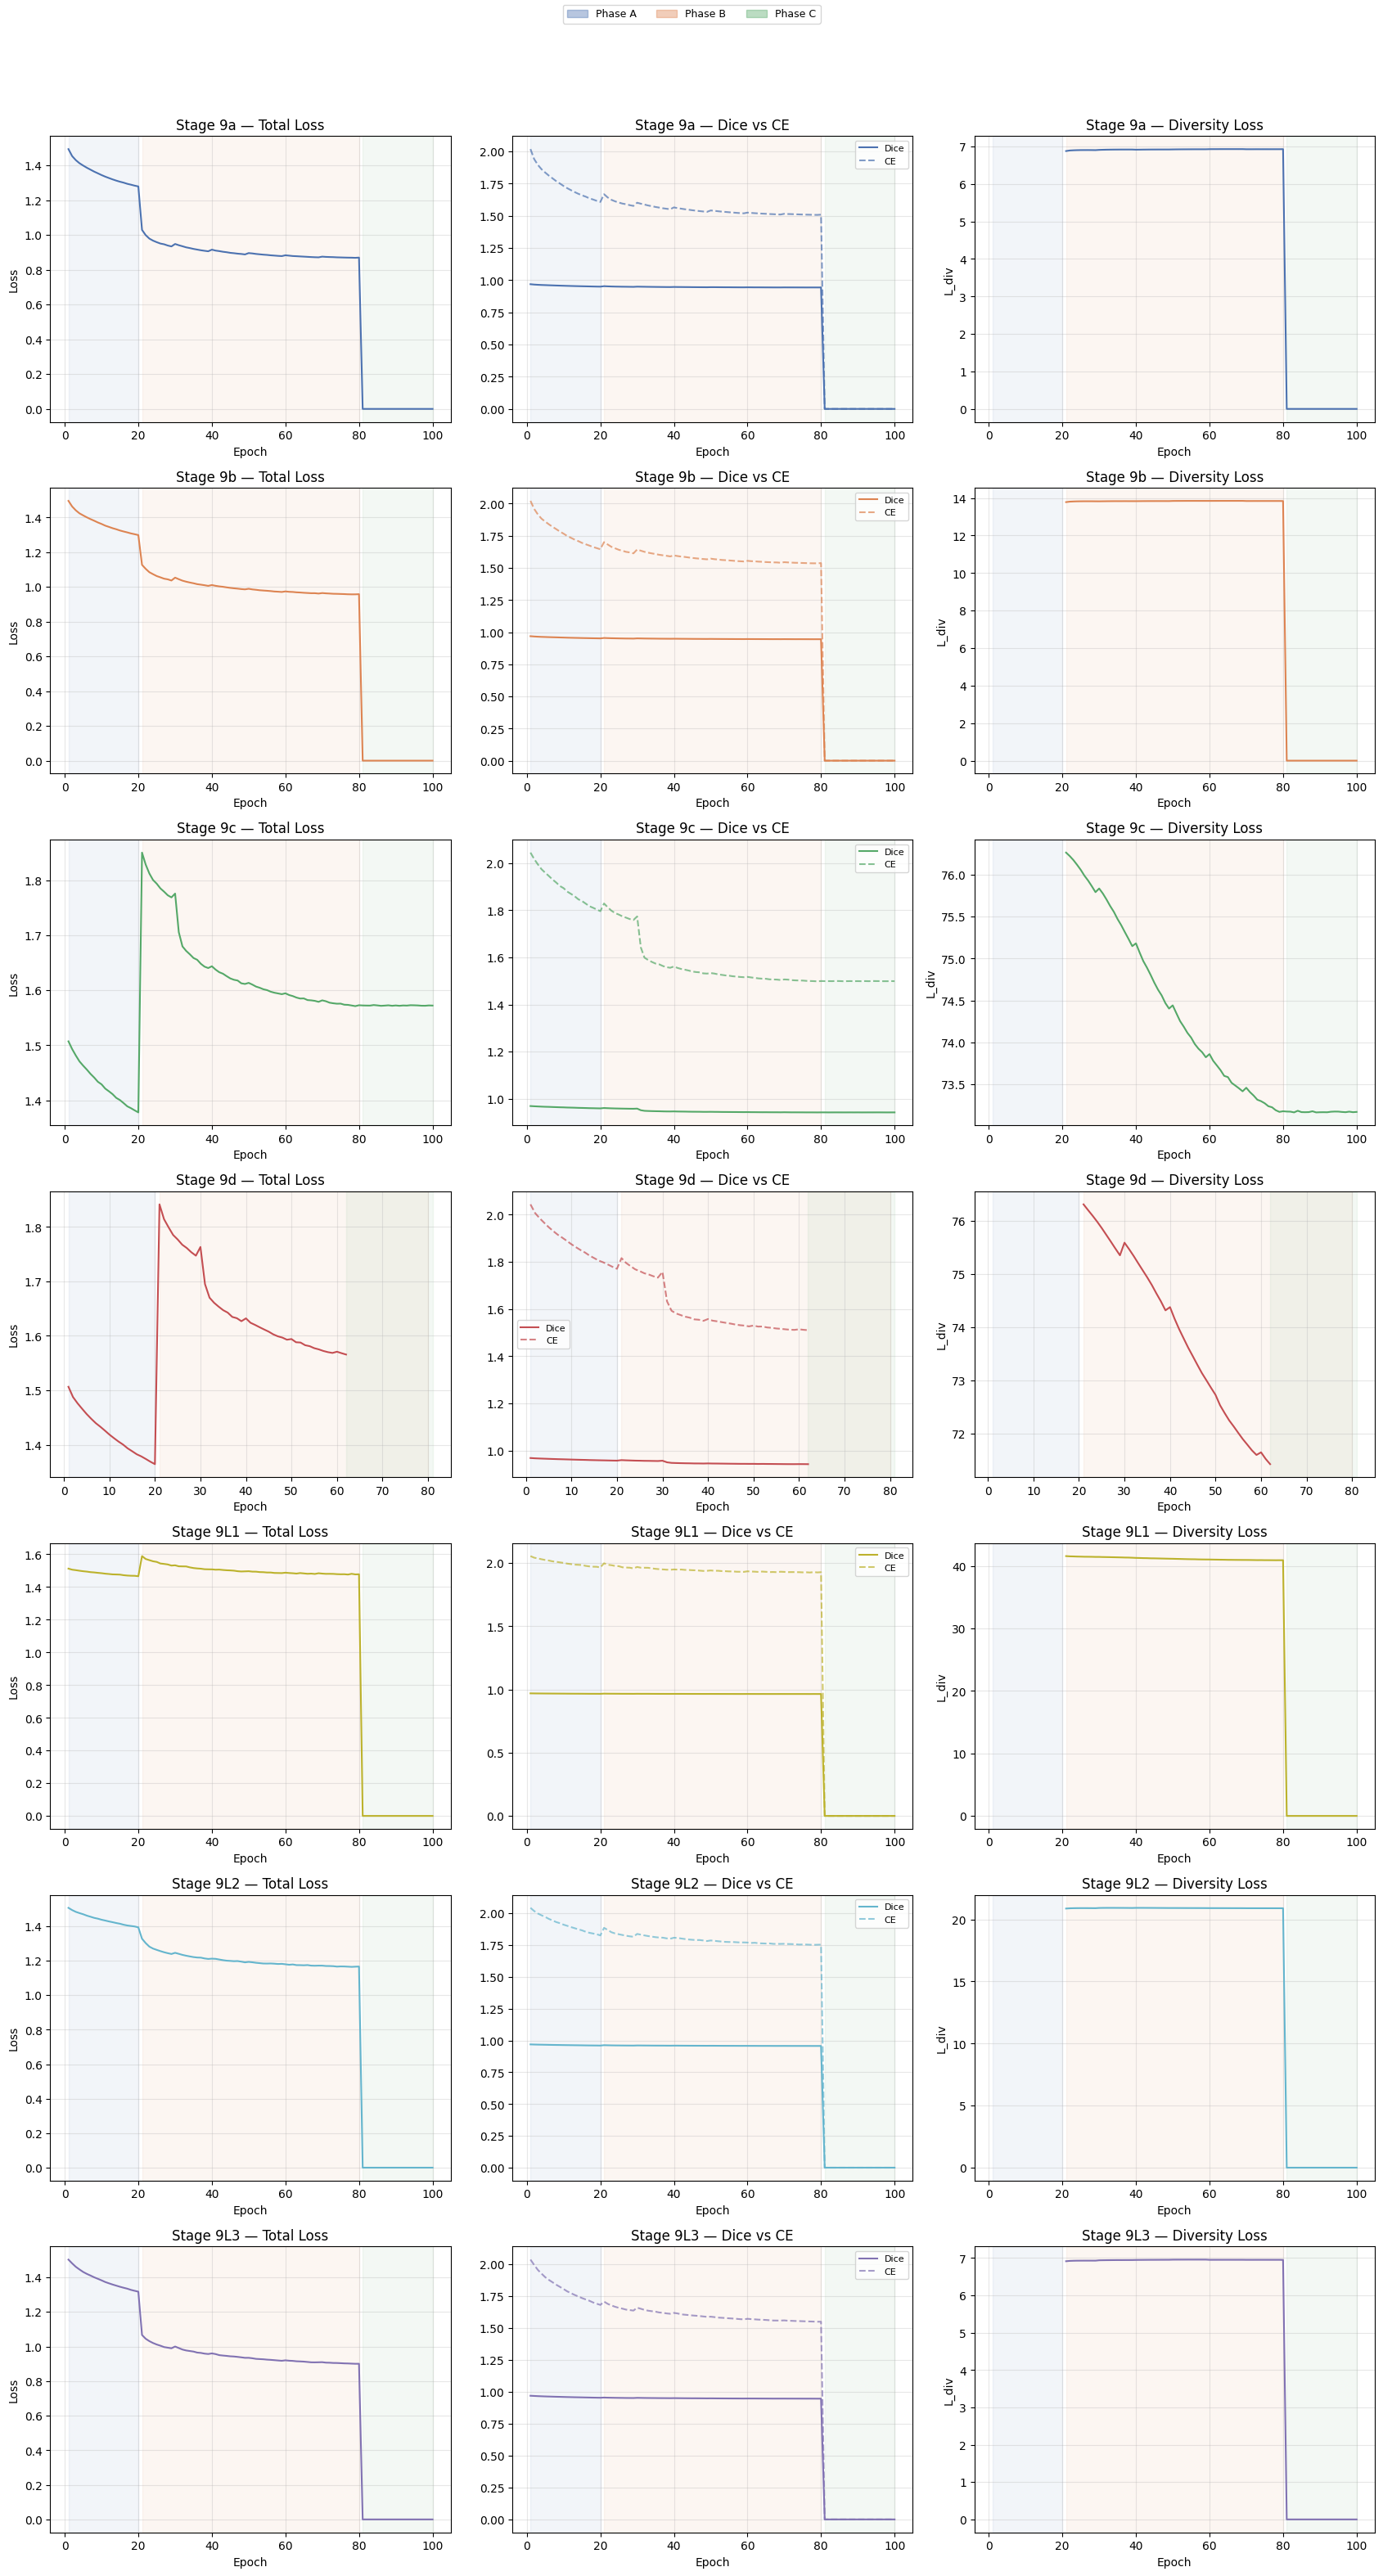

In [12]:
from matplotlib.patches import Patch

if not logs:
    print('No logs found — run training first.')
else:
    STAGE_COLORS = {'9a': '#4C72B0', '9b': '#DD8452', '9c': '#55A868', '9d': '#C44E52', '9L1': '#BCB22C', '9L2': '#64B5CD', '9L3': '#8172B2'}
    n = len(logs)
    fig, axes = plt.subplots(n, 3, figsize=(17, 4.5 * max(n, 1)), squeeze=False)

    for row, (st, log) in enumerate(logs.items()):
        ep = log['epoch']
        max_ep = ep.max()
        for ax in axes[row]:
            ax.axvspan(1,  PHASE_A_END,           alpha=0.07, color=PHASE_COLORS['A'])
            ax.axvspan(PHASE_A_END+1, PHASE_B_END, alpha=0.07, color=PHASE_COLORS['B'])
            ax.axvspan(PHASE_B_END+1, max_ep,      alpha=0.07, color=PHASE_COLORS['C'])

        col = STAGE_COLORS[st]
        axes[row, 0].plot(ep, log['train_loss'], lw=1.5, color=col)
        axes[row, 0].set(title=f'Stage {st} — Total Loss', ylabel='Loss', xlabel='Epoch')
        axes[row, 0].grid(alpha=0.3)

        axes[row, 1].plot(ep, log['train_dice_loss'], lw=1.5, label='Dice', color=col)
        axes[row, 1].plot(ep, log['train_ce_loss'],   lw=1.5, label='CE',   color=col, ls='--', alpha=0.7)
        axes[row, 1].set(title=f'Stage {st} — Dice vs CE', xlabel='Epoch')
        axes[row, 1].legend(fontsize=8); axes[row, 1].grid(alpha=0.3)

        div = log[log['phase'].isin(['B', 'C'])]
        axes[row, 2].plot(div['epoch'], div['train_div_loss'], lw=1.5, color=col)
        axes[row, 2].set(title=f'Stage {st} — Diversity Loss', ylabel='L_div', xlabel='Epoch')
        axes[row, 2].grid(alpha=0.3)

    legend_els = [Patch(color=PHASE_COLORS[p], alpha=0.4, label=f'Phase {p}') for p in 'ABC']
    fig.legend(handles=legend_els, loc='upper center', ncol=3, fontsize=9)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.savefig(RESULT_DIR / f'35_loss_curves_{MODALITY}.png', dpi=130)
    plt.show()

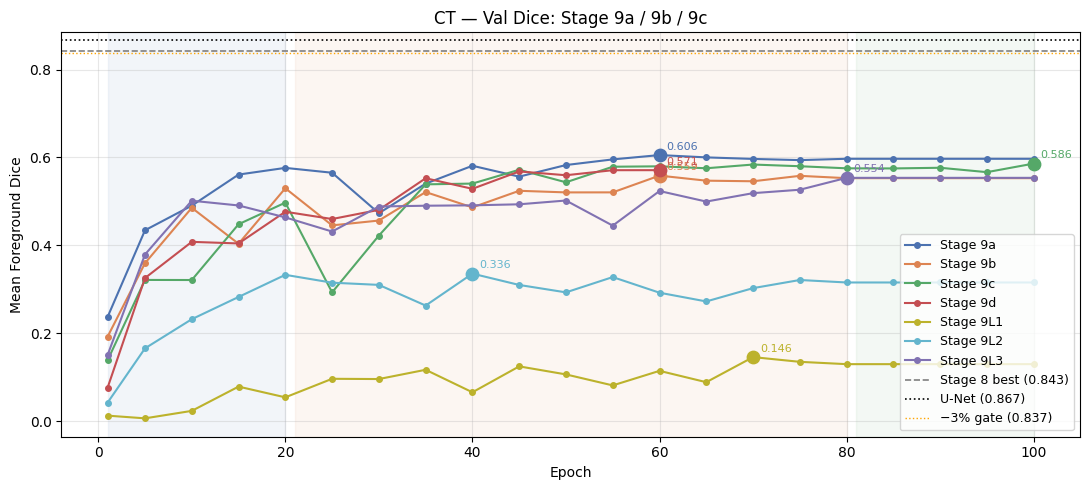

In [13]:
# Val Dice — all stages on one plot + baselines
BASELINES = {'ct': 0.843, 'mr': 0.825}   # Stage 8 best (ProtoSegNet L2)
UNET_BASE = {'ct': 0.867, 'mr': 0.825}   # U-Net baseline

if logs:
    STAGE_COLORS = {'9a': '#4C72B0', '9b': '#DD8452', '9c': '#55A868', '9d': '#C44E52', '9L1': '#BCB22C', '9L2': '#64B5CD', '9L3': '#8172B2'}
    fig, ax = plt.subplots(figsize=(11, 5))
    max_ep_all = max(log['epoch'].max() for log in logs.values())

    ax.axvspan(1,  PHASE_A_END,           alpha=0.07, color=PHASE_COLORS['A'])
    ax.axvspan(PHASE_A_END+1, PHASE_B_END, alpha=0.07, color=PHASE_COLORS['B'])
    ax.axvspan(PHASE_B_END+1, max_ep_all,  alpha=0.07, color=PHASE_COLORS['C'])

    for st, log in logs.items():
        val = log.dropna(subset=['val_mean_fg_dice'])
        ax.plot(val['epoch'], val['val_mean_fg_dice'], 'o-', ms=4, lw=1.5,
                color=STAGE_COLORS[st], label=f'Stage {st}')
        best_row = val.loc[val['val_mean_fg_dice'].idxmax()]
        ax.scatter(best_row['epoch'], best_row['val_mean_fg_dice'],
                   s=80, color=STAGE_COLORS[st], zorder=5)
        ax.annotate(f"{best_row['val_mean_fg_dice']:.3f}",
                    (best_row['epoch'], best_row['val_mean_fg_dice']),
                    textcoords='offset points', xytext=(5, 4), fontsize=8,
                    color=STAGE_COLORS[st])

    ax.axhline(BASELINES[MODALITY], color='gray',   ls='--', lw=1.2,
               label=f'Stage 8 best ({BASELINES[MODALITY]:.3f})')
    ax.axhline(UNET_BASE[MODALITY], color='black',  ls=':',  lw=1.2,
               label=f'U-Net ({UNET_BASE[MODALITY]:.3f})')
    ax.axhline(UNET_BASE[MODALITY] - 0.03, color='orange', ls=':', lw=1,
               label=f'−3% gate ({UNET_BASE[MODALITY]-0.03:.3f})')

    ax.set(title=f'{MODALITY.upper()} — Val Dice: Stage 9a / 9b / 9c',
           xlabel='Epoch', ylabel='Mean Foreground Dice')
    ax.legend(fontsize=9, loc='lower right'); ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(RESULT_DIR / f'35_val_dice_{MODALITY}.png', dpi=130)
    plt.show()

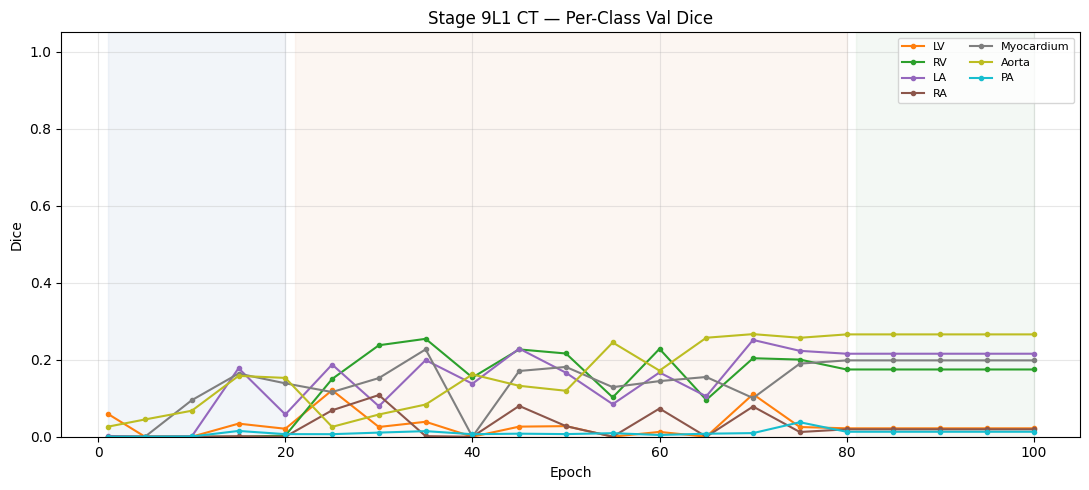

In [14]:
# Per-class val Dice for current STAGE
STAGE_COLORS = {'9a': '#4C72B0', '9b': '#DD8452', '9c': '#55A868', '9d': '#C44E52', '9L1': '#BCB22C', '9L2': '#64B5CD', '9L3': '#8172B2'}

if STAGE in logs:
    log = logs[STAGE]
    val = log.dropna(subset=['val_mean_fg_dice'])
    max_ep = log['epoch'].max()
    cmap = plt.get_cmap('tab10', NUM_CLASSES)

    fig, ax = plt.subplots(figsize=(11, 5))
    ax.axvspan(1,  PHASE_A_END,           alpha=0.07, color=PHASE_COLORS['A'])
    ax.axvspan(PHASE_A_END+1, PHASE_B_END, alpha=0.07, color=PHASE_COLORS['B'])
    ax.axvspan(PHASE_B_END+1, max_ep,      alpha=0.07, color=PHASE_COLORS['C'])

    for c in range(1, NUM_CLASSES):
        col_name = f'val_dice_{LABEL_NAMES[c]}'
        if col_name in val.columns:
            ax.plot(val['epoch'], pd.to_numeric(val[col_name], errors='coerce'),
                    label=LABEL_NAMES[c], color=cmap(c), lw=1.5, marker='o', ms=3)

    ax.set(title=f'Stage {STAGE} {MODALITY.upper()} — Per-Class Val Dice',
           xlabel='Epoch', ylabel='Dice', ylim=(0, 1.05))
    ax.legend(fontsize=8, ncol=2); ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(RESULT_DIR / f'35_per_class_{MODALITY}_{STAGE}.png', dpi=130)
    plt.show()
else:
    print(f'Stage {STAGE} log not found.')

---
## 5 · XAI Evaluation

Prototype quality and explanation metrics for the trained stage.

| Metric | Min gate | Target |
|--------|----------|--------|
| AP | ≥ 0.15 | ≥ 0.25 |
| Faithfulness | ≥ 0.15 | ≥ 0.30 |
| Stability | ≤ 2.00 | ≤ 1.00 |

In [15]:
# ── Load trained model + projected prototypes ─────────────────────────────────
import torch.utils.data as tud
from src.metrics.activation_precision import activation_precision_patient
from src.metrics.faithfulness import faithfulness_patient
from src.metrics.stability import stability_patient
from src.metrics.proto_quality import (
    compute_purity, compute_per_level_ap, compute_compactness,
    compute_level_dominance, compute_effective_quality,
)

ckpt_path = CKPT_DIR / f'proto_seg_{MODALITY}{SUFFIX}.pth'
proj_path = CKPT_DIR / f'projected_prototypes_{MODALITY}{SUFFIX}.pt'

xai_model = ProtoSegNetV2(
    n_classes=NUM_CLASSES, proto_levels=PROTO_LEVELS, use_attention=USE_ATTENTION
).to(DEVICE)
ckpt = torch.load(ckpt_path, map_location='cpu', weights_only=True)
xai_model.load_state_dict(ckpt['model_state_dict'])

if proj_path.exists():
    proj = torch.load(proj_path, map_location='cpu', weights_only=True)
    for level, data in proj['proto_state'].items():
        xai_model.proto_layers[str(level)].prototypes.data.copy_(data)
    print(f'Projected prototypes loaded from {proj_path.name}')
else:
    print('WARNING: no projection file found — using trained (unprojected) prototypes')

xai_model.eval()
print(f'Loaded checkpoint: epoch={ckpt["epoch"]}  val_dice={ckpt["best_val_dice"]:.4f}')

test_ds  = MMWHSSliceDataset(DATA_DIR, MODALITY, 'test',  augment=False, preload=True)
train_ds = MMWHSSliceDataset(DATA_DIR, MODALITY, 'train', augment=False, preload=True)
test_loader  = tud.DataLoader(test_ds,  batch_size=16, shuffle=False)
train_loader = tud.DataLoader(train_ds, batch_size=16, shuffle=False)
print(f'Test: {len(test_ds)} slices  Train: {len(train_ds)} slices')

Projected prototypes loaded from projected_prototypes_ct_v2_l1.pt
Loaded checkpoint: epoch=70  val_dice=0.1457


Test: 484 slices  Train: 3389 slices


In [16]:
# ── Prototype quality metrics ─────────────────────────────────────────────────
print('Computing purity…')
purity_df    = compute_purity(xai_model, train_loader)

print('Computing AP…')
ap_df        = compute_per_level_ap(xai_model, test_loader)

print('Computing compactness…')
compact_df   = compute_compactness(xai_model, test_loader)

print('Computing dominance…')
dom_df       = compute_level_dominance(xai_model, test_loader)

print('Computing effective quality…')
eq_df        = compute_effective_quality(purity_df, ap_df, compact_df, dom_df)

# Save
purity_df.to_csv(RESULT_DIR / f'xai_purity_{STAGE}.csv',    index=False)
ap_df.to_csv    (RESULT_DIR / f'xai_ap_{STAGE}.csv',         index=False)
eq_df.to_csv    (RESULT_DIR / f'xai_effective_quality_{STAGE}.csv', index=False)

print()
print('─── Per-level AP ───')
print(ap_df.groupby('level')[['ap']].mean().round(3).to_string())
print()
print('─── Effective quality ───')
print(eq_df.round(3).to_string(index=False))

Computing purity…


Computing AP…


Computing compactness…


Computing dominance…


Computing effective quality…

─── Per-level AP ───
          ap
level       
1      0.166

─── Effective quality ───
 weight_l1  purity_l1  ap_l1  compact_l1  effective_purity  effective_ap  effective_compactness
       1.0      0.159  0.166       0.163             0.159         0.166                  0.163


In [17]:
# ── Faithfulness & Stability (up to 50 test slices for speed) ─────────────────
imgs_test = torch.stack([test_ds[i]['image'] for i in range(len(test_ds))])

print('Computing faithfulness (may take a few minutes)…')
faith = faithfulness_patient(xai_model, imgs_test, DEVICE, max_slices=50)
print(f'  Faithfulness: {faith["faithfulness"]:.4f}  (std {faith["faithfulness_std"]:.4f})')

print('Computing stability…')
stab = stability_patient(xai_model, imgs_test, DEVICE, max_slices=50)
print(f'  Stability:    {stab["stability"]:.4f}  (std {stab["stability_std"]:.4f})')

import pandas as pd
pd.DataFrame([faith]).to_csv(RESULT_DIR / f'xai_faithfulness_{STAGE}.csv', index=False)
pd.DataFrame([stab]).to_csv (RESULT_DIR / f'xai_stability_{STAGE}.csv',    index=False)

Computing faithfulness (may take a few minutes)…


  Faithfulness: 0.1603  (std 0.1207)
Computing stability…


  Stability:    16.9997  (std 1.5540)


In [18]:
# ── Summary table with decision gates ────────────────────────────────────────
import pandas as pd

eff_ap    = float(eq_df['effective_ap'].iloc[0])
eff_pur   = float(eq_df['effective_purity'].iloc[0])
eff_comp  = float(eq_df['effective_compactness'].iloc[0])
faith_val = faith['faithfulness']
stab_val  = stab['stability']
val_dice  = ckpt['best_val_dice']

rows = [
    ('Val Dice',            val_dice,  None,   None,   '—'),
    ('Effective Purity',    eff_pur,   None,   None,   '—'),
    ('Effective AP',        eff_ap,    0.15,   0.25,   '✅' if eff_ap >= 0.15 else '❌'),
    ('Effective Compact.',  eff_comp,  None,   None,   '—'),
    ('Faithfulness',        faith_val, 0.15,   0.30,   '✅' if faith_val >= 0.15 else '❌'),
    ('Stability',           stab_val,  None,   2.00,   '✅' if stab_val <= 2.00 else '❌'),
]

summary = pd.DataFrame(rows, columns=['Metric', 'Value', 'Min gate', 'Target', 'Pass'])
summary['Value'] = summary['Value'].apply(lambda v: f'{v:.4f}' if v is not None else '—')
summary['Min gate'] = summary['Min gate'].apply(lambda v: f'{v:.2f}' if v is not None else '—')
summary['Target']   = summary['Target'].apply(lambda v: f'{v:.2f}' if v is not None else '—')

print(f'\nStage {STAGE} — {MODALITY.upper()} — XAI Summary')
print('=' * 58)
print(summary.to_string(index=False))
print()
summary.to_csv(RESULT_DIR / f'xai_summary_{STAGE}.csv', index=False)


Stage 9L1 — CT — XAI Summary
            Metric   Value Min gate Target Pass
          Val Dice  0.1457      nan    nan    —
  Effective Purity  0.1593      nan    nan    —
      Effective AP  0.1659     0.15   0.25    ✅
Effective Compact.  0.1630      nan    nan    —
      Faithfulness  0.1603     0.15   0.30    ✅
         Stability 16.9997      nan   2.00    ❌



---
## 6 · Attention Weight Evolution (Stage 9c)

Expected behaviour:
- **ep 21–30:** uniform (~0.25) — attention frozen
- **ep 31–71:** L1/L2 decay toward 0; L4 rises toward > 0.50
- **ep 72+:** stable — T=1 (no further annealing)

Anomaly flags: L2 > 0.10 after ep 60 | L4 < 0.30 at ep 80 | oscillation > ±0.05/ep

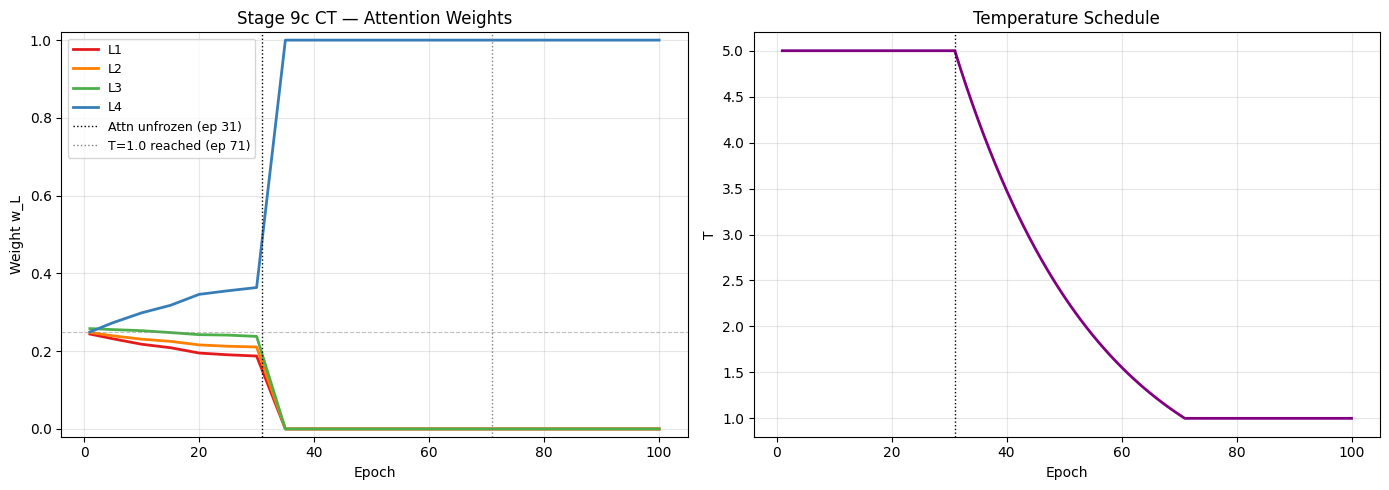


Anomaly check (ep ≥ 60):
  L2 max after ep 60: 0.000  ✅ (threshold 0.10)
  L4 min after ep 60: 1.000  ✅ (threshold 0.30)


In [19]:
log_9c_path = RESULT_DIR / f'train_curve_proto_{MODALITY}_v2.csv'
if not log_9c_path.exists():
    print('Stage 9c log not found — run training first.')
else:
    log9c = pd.read_csv(log_9c_path)
    attn_cols_found = [c for c in log9c.columns if c.startswith('attn_w_L')]

    if not attn_cols_found:
        print('No attention columns in log — was USE_ATTENTION=True?')
    else:
        val9c = log9c.dropna(subset=attn_cols_found)
        level_colors = {1: '#e41a1c', 2: '#ff7f00', 3: '#4daf4a', 4: '#377eb8'}

        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        # Left: attention weights over epochs
        ax = axes[0]
        for col in attn_cols_found:
            l = int(col.split('_L')[1])
            ax.plot(val9c['epoch'], val9c[col], lw=2, label=f'L{l}',
                    color=level_colors.get(l, 'gray'))
        ax.axvline(ATTN_WARMUP_END + 1, color='black', ls=':', lw=1, label='Attn unfrozen (ep 31)')
        ax.axvline(ANNEAL_START + ANNEAL_EPOCHS, color='gray', ls=':', lw=1,
                   label=f'T=1.0 reached (ep {ANNEAL_START + ANNEAL_EPOCHS})')
        ax.axhline(0.25, color='gray', ls='--', lw=0.8, alpha=0.5)
        ax.set(title=f'Stage 9c {MODALITY.upper()} — Attention Weights',
               xlabel='Epoch', ylabel='Weight w_L', ylim=(-0.02, 1.02))
        ax.legend(fontsize=9); ax.grid(alpha=0.3)

        # Right: temperature schedule
        ax = axes[1]
        ep_range = log9c['epoch'].values
        T_vals = []
        for ep in ep_range:
            if ep < ANNEAL_START:
                T_vals.append(T_START)
            else:
                p = (ep - ANNEAL_START) / ANNEAL_EPOCHS
                T_vals.append(max(T_END, T_START * (T_END / T_START) ** min(p, 1.0)))
        ax.plot(ep_range, T_vals, lw=2, color='purple')
        ax.axvline(ATTN_WARMUP_END + 1, color='black', ls=':', lw=1)
        ax.set(title='Temperature Schedule', xlabel='Epoch', ylabel='T')
        ax.grid(alpha=0.3)

        plt.tight_layout()
        plt.savefig(RESULT_DIR / f'35_attn_weights_{MODALITY}.png', dpi=130)
        plt.show()

        # Anomaly check
        print('\nAnomaly check (ep ≥ 60):')
        late = val9c[val9c['epoch'] >= 60]
        if 'attn_w_L2' in late.columns:
            l2_max = late['attn_w_L2'].max()
            flag = '⚠️' if l2_max > 0.10 else '✅'
            print(f'  L2 max after ep 60: {l2_max:.3f}  {flag} (threshold 0.10)')
        if 'attn_w_L4' in late.columns:
            l4_min = late['attn_w_L4'].min()
            flag = '⚠️' if l4_min < 0.30 else '✅'
            print(f'  L4 min after ep 60: {l4_min:.3f}  {flag} (threshold 0.30)')

---
## 7 · Notes

### Decision gates (before proceeding to next stage)

| Stage | Metric | Minimum | Target |
|-------|--------|---------|--------|
| 9a | AP | ≥ 0.15 | ≥ 0.25 |
| 9a | Faithfulness | ≥ 0.15 | ≥ 0.30 |
| 9b | Dice CT | — | > 9a Dice |
| 9c | Dice CT | ≥ 0.80 | ≥ 0.83 |
| 9c | L1+L2 attn weight | — | ≤ 0.05 |
| any | Stability | ≤ 2.00 | ≤ 1.00 |

**If AP < 0.10 in Stage 9a (lower than Stage 8):** stop and diagnose — the bypass invariant may not hold for a non-trivial reason.

**If Dice drops > 0.07 vs Stage 8:** consider adding a lightweight 2-layer CNN head (still no skip connections) between heatmaps and logits.

### Subsequent steps
- Run `scripts/proto_quality.py` for purity / compactness / dominance per level
- Run XAI evaluation (AP, IDS, Faithfulness, Stability) on all three checkpoints
- Produce Stage 10 comparison table: all three new models + v1–v8 baselines